In [8]:
import os
import warnings

# Suppress all warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
warnings.filterwarnings('ignore')

import tensorflow as tf
import numpy as np
import cv2
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras.applications.efficientnet import preprocess_input as pi_e
import seaborn as sns
import matplotlib.pyplot as plt
import random
from sklearn.model_selection import train_test_split
import tf_slim
import kagglehub
import json

# Check versions
print(f"TensorFlow: {tf.__version__}")
print(f"NumPy: {np.__version__}")
print(f"OpenCV: {cv2.__version__}")

import sys
print(sys.version)

TensorFlow: 2.19.0
NumPy: 2.4.6
OpenCV: 4.13.0
3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [9]:
dataset_path = kagglehub.dataset_download("kmader/food41")
IMAGE_ROOT   = os.path.join(dataset_path, "images")
meta_dir     = os.path.join(dataset_path, "meta", "meta")

with open(os.path.join(meta_dir, "classes.txt")) as f:
    CLASS_NAMES = f.read().splitlines()          # 101 class names

with open(os.path.join(meta_dir, "train.json")) as f:
    train_data = json.load(f)   # {class: ["class/img_id", …]}

with open(os.path.join(meta_dir, "test.json")) as f:
    test_data  = json.load(f)

print(f"Classes  : {len(CLASS_NAMES)}")
print(f"Sample train keys : {list(train_data.keys())[:5]}")
print(f"Sample test  keys : {list(test_data.keys())[:5]}")


Classes  : 101
Sample train keys : ['churros', 'hot_and_sour_soup', 'samosa', 'sashimi', 'pork_chop']
Sample test  keys : ['churros', 'hot_and_sour_soup', 'samosa', 'sashimi', 'pork_chop']


In [10]:
from tensorflow.keras import layers, Model, metrics
from tensorflow.keras.applications import EfficientNetB2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import plot_model


# ── Image ─────────────────────────────────────────────────────────────────────
IMG_SIZE   = 224
IMG_SHAPE  = (IMG_SIZE, IMG_SIZE, 3)
AUTOTUNE   = tf.data.AUTOTUNE

# ── Model ─────────────────────────────────────────────────────────────────────
EMBEDDING_DIM  = 128
MARGIN         = 0.5
DROPOUT_RATE   = 0.4

# ── Training ──────────────────────────────────────────────────────────────────
BATCH_SIZE        = 64      # lower to 32 if OOM
EPOCHS_PHASE1     = 15
EPOCHS_PHASE2     = 25
PATIENCE          = 5
LR_PHASE1         = 1e-3
LR_PHASE2         = 1e-5

# ── Triplet sampling ──────────────────────────────────────────────────────────
N_TRAIN_TRIPLETS  = 200     # per class  →  ~20 200 total
N_TEST_TRIPLETS   = 50

# ── Support set ───────────────────────────────────────────────────────────────
N_SHOTS_PER_CLASS  = 10     # images per class used to build prototype
# Set to None to use ALL images per class (slower but more accurate)
MAX_IMAGES_PER_CLASS = None  # e.g. 50  to cap memory usage; None = all


In [11]:
def build_class_index(data: dict) -> dict:
    """Returns {class_name: [relative_img_path, …]}."""
    return {cls: list(paths) for cls, paths in data.items()}

def generate_triplets(class_index: dict, n_per_class: int) -> list:
    """
    For every class c:
      - sample anchor & positive from c
      - sample negative from a random different class
    """
    classes  = list(class_index.keys())
    triplets = []
    for cls in classes:
        imgs = class_index[cls]
        if len(imgs) < 2:
            continue
        for _ in range(n_per_class):
            a, p    = random.sample(imgs, 2)
            neg_cls = random.choice([c for c in classes if c != cls])
            n       = random.choice(class_index[neg_cls])
            triplets.append((a, p, n))
    random.shuffle(triplets)
    return triplets

train_class_idx = build_class_index(train_data)
test_class_idx  = build_class_index(test_data)

train_triplets  = generate_triplets(train_class_idx, N_TRAIN_TRIPLETS)
test_triplets   = generate_triplets(test_class_idx,  N_TEST_TRIPLETS)

print(f"Train triplets : {len(train_triplets):,}")
print(f"Test  triplets : {len(test_triplets):,}")
print(f"\nSample triplet (relative paths):")
a, p, n = train_triplets[0]
print(f"  Anchor   : {a}")
print(f"  Positive : {p}")
print(f"  Negative : {n}")


Train triplets : 20,200
Test  triplets : 5,050

Sample triplet (relative paths):
  Anchor   : spaghetti_bolognese/3616046
  Positive : spaghetti_bolognese/349067
  Negative : apple_pie/505249


In [12]:
GLOBAL_IMAGE_CACHE = {}

def read_image(dir_path, img_id):
    cache_key = f"{dir_path}/{img_id}"
    if cache_key in GLOBAL_IMAGE_CACHE:
        return GLOBAL_IMAGE_CACHE[cache_key]
        
    # Correctly append .jpg to the dataset string
    path = os.path.join(dir_path, f"{img_id}.jpg")
    
    image = cv2.imread(path)
    if image is None:
        print(f"Warning: Failed to load image at {path}. Returning zeros.")
        return np.zeros((260, 260, 3), dtype=np.uint8)
        
    image = cv2.resize(image, (260,260))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    GLOBAL_IMAGE_CACHE[cache_key] = image
    return image

def get_batch(triplet_list, flag, batch_size=128, preprocess=True):
    batch_steps = len(triplet_list) // batch_size
    
    # Force it to use the downloaded kagglehub dataset path 
    path = IMAGE_ROOT
    
    for i in range(batch_steps + 1):
        anchor   = []
        positive = []
        negative = []
        
        j = i * batch_size
        while j < (i + 1) * batch_size and j < len(triplet_list):
            a, p, n = triplet_list[j]
            
            img_a = read_image(path, a)
            img_p = read_image(path, p)
            img_n = read_image(path, n)
            
            anchor.append(img_a)
            positive.append(img_p)
            negative.append(img_n)
            j += 1
            
        if len(anchor) == 0:
            continue
        
        anchor   = np.array(anchor, dtype=np.float32)
        positive = np.array(positive, dtype=np.float32)
        negative = np.array(negative, dtype=np.float32)
        
        if preprocess:
            anchor = pi_e(anchor)
            positive = pi_e(positive)
            negative = pi_e(negative)
            
        yield ([anchor, positive, negative])
        
    print("--- GENERATOR FINISHED ---")

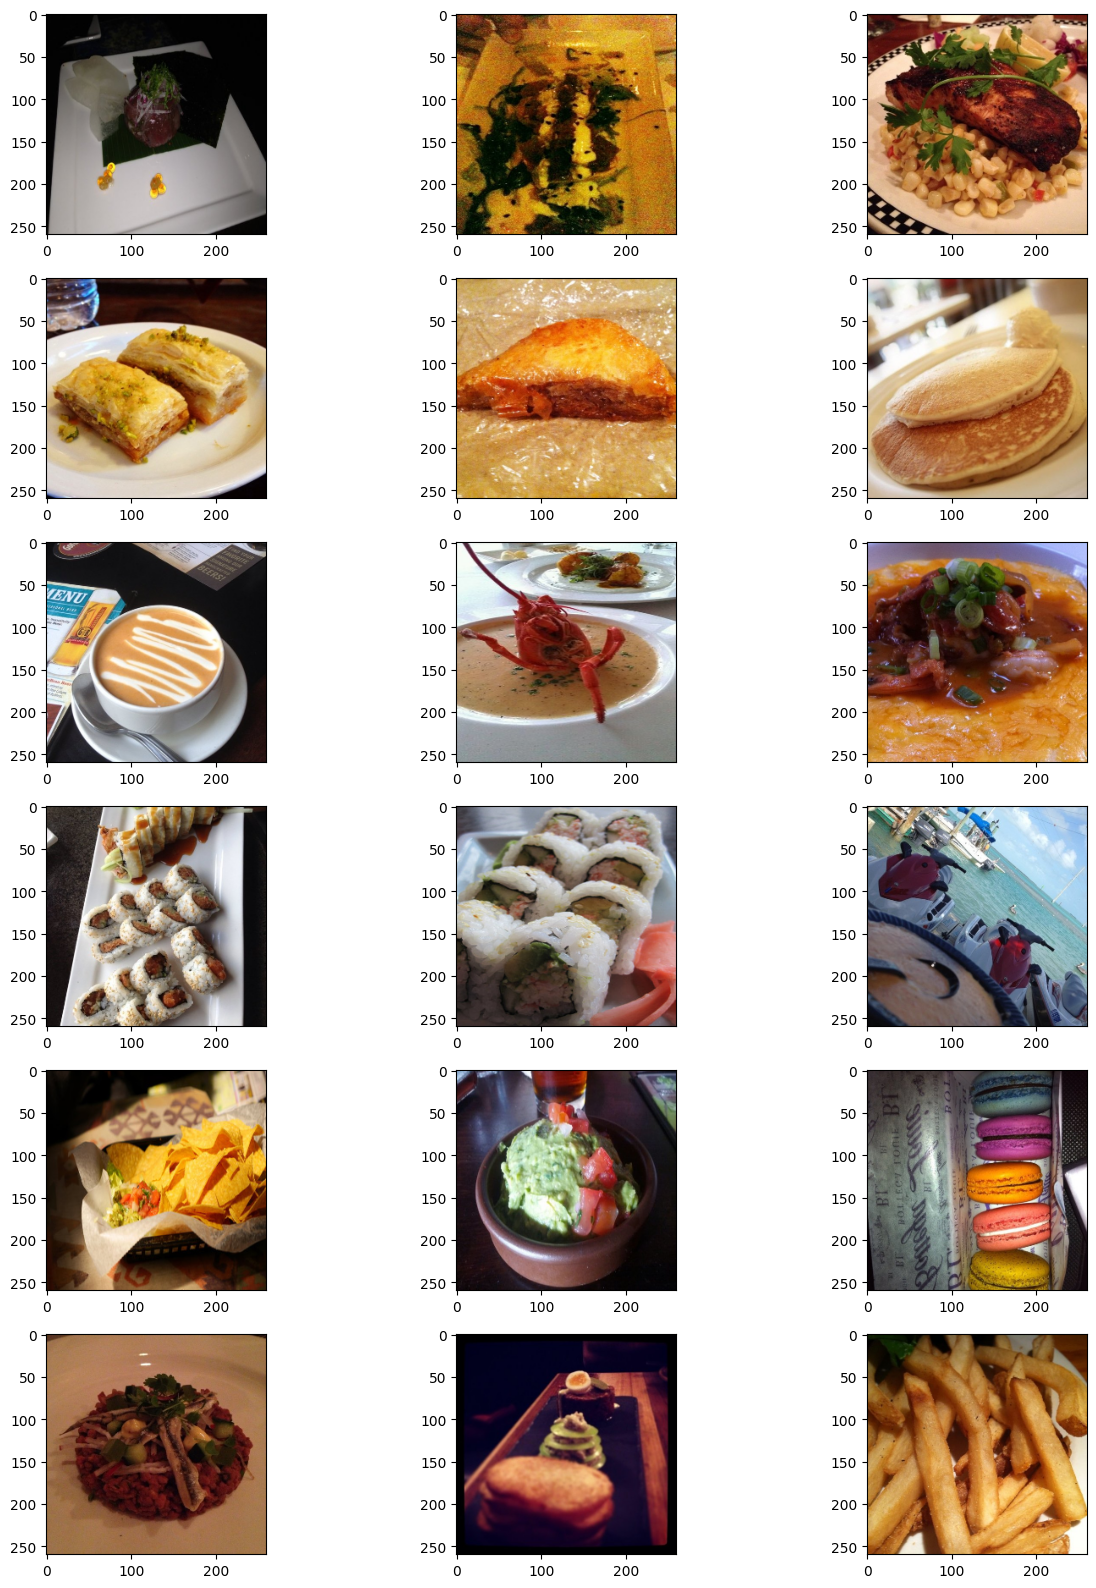

In [7]:
num_plots = 6

f, axes = plt.subplots(num_plots, 3, figsize=(15, 20))

for x in get_batch(train_triplets,0, batch_size=num_plots, preprocess=False):
    a,p,n = x
    for i in range(num_plots):
        axes[i, 0].imshow(a[i].astype('float32') / 255.0)
        axes[i, 1].imshow(p[i].astype('float32') / 255.0)
        axes[i, 2].imshow(n[i].astype('float32') / 255.0)
        i+=1
    break

In [13]:
def get_encoder(input_shape=(260,260,3),dropout_rate=0.5):
    """ Returns the image encoding model """
    """
    pretrained_model = Xception(
        input_shape=input_shape,
        weights='/kaggle/input/data-xc/xception_weights_tf_dim_ordering_tf_kernels_notop.h5',
        include_top=False,
        pooling=None,
    )"""

    pt_model=EfficientNetB2(
        input_shape=input_shape,
        weights='imagenet',
        include_top=False,
        pooling=None,
    )
    
    
    pt_model.trainable = False
    
   
    x = pt_model.output

    x = layers.SpatialDropout2D(0.2)(x)

    # Global pooling + dense head
    x = layers.GlobalAveragePooling2D()(x)
    
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)
    
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    
    x = layers.Dense(128)(x)
    x = layers.Lambda(lambda x: tf.math.l2_normalize(x, axis=1))(x)

    encode_model = Model(inputs=pt_model.input, outputs=x, name="Encode_Model")
    return encode_model


In [14]:
class DistanceLayer(layers.Layer):
    # A layer to compute ‖f(A) - f(P)‖² and ‖f(A) - f(N)‖²
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
    def get_config(self):
        return super().get_config()
    def call(self, anchor, positive, negative):
        ap_distance = tf.reduce_sum(tf.square(anchor - positive), -1)
        an_distance = tf.reduce_sum(tf.square(anchor - negative), -1)
        return (ap_distance, an_distance)

def get_siamese_network(input_shape = (260, 260, 3)):

    encoder = get_encoder(input_shape)
    
    # Input Layers for the images
    anchor_input   = layers.Input(input_shape, name="Anchor_Input") 
    positive_input = layers.Input(input_shape, name="Positive_Input")
    negative_input = layers.Input(input_shape, name="Negative_Input")
    inp=[anchor_input,positive_input,negative_input]
    distances = DistanceLayer()(
        encoder(anchor_input),
        encoder(positive_input),
        encoder(negative_input)
    )
    
    # A layer to compute ‖f(A) - f(P)‖² and ‖f(A) - f(N)‖²

    
    # Creating the Model
    siamese_network = Model(
        inputs  = inp,
        outputs = distances,
        name = "Siamese_Network"
    )
    return siamese_network

siamese_network = get_siamese_network()
siamese_network.summary()

31790344/31790344 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "Siamese_Network"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Anchor_Input        │ (None, 260, 260,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Positive_Input      │ (None, 260, 260,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Negative_Input      │ (None, 260, 260,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Encode_Model        │ (None, 128)       │  8,657,273 │ Anchor_Input[0][… │
│ (Functional)        │                   │            │ Positive_Input[0… │
│                     │                   │            │ Negative_Input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ distance_layer      │ [(None), (None)]  │          0 │ Encode_Model[0][… │
│ (DistanceLayer)     │                   │            │ Encode_Model[1][… │
│                     │                   │            │ Encode_Model[2][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8,657,273 (33.02 MB)

 Trainable params: 887,168 (3.38 MB)

 Non-trainable params: 7,770,105 (29.64 MB)

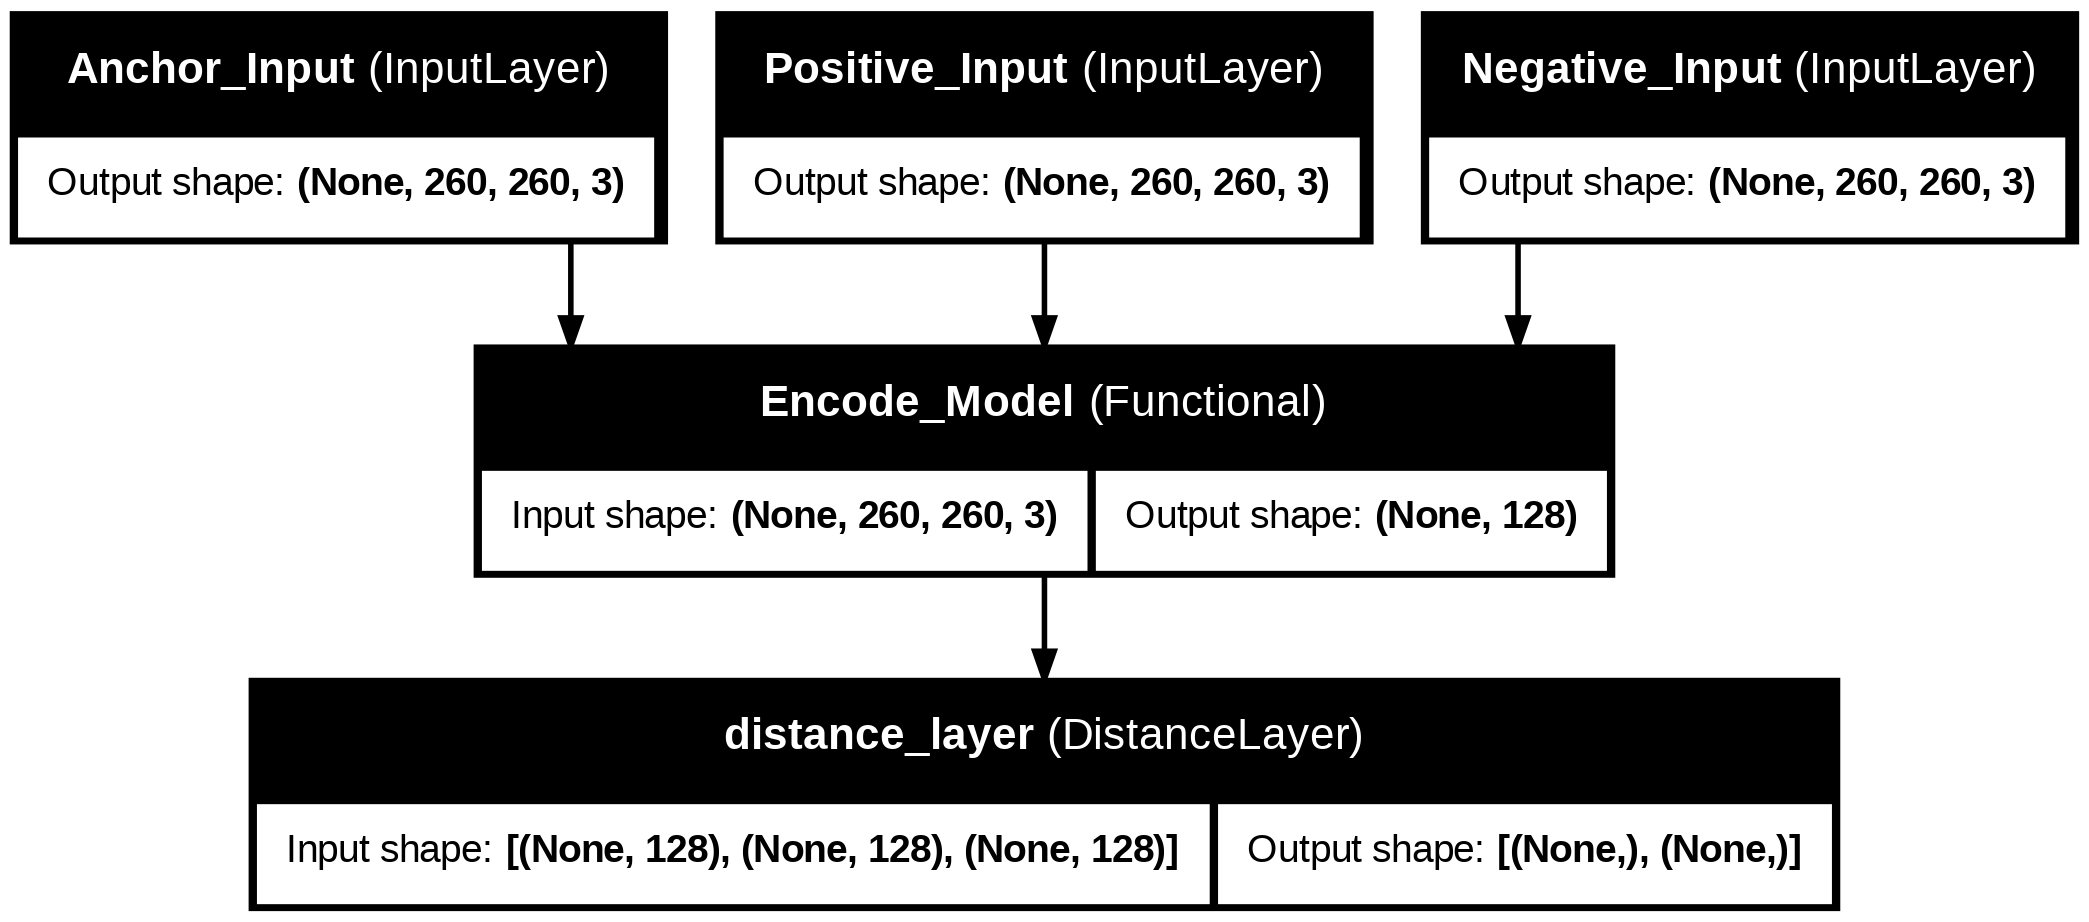

In [10]:
plot_model(siamese_network, show_shapes=True, show_layer_names=True)

In [15]:
class SiameseModel(Model):
    # Builds a Siamese model based on a base-model
    def __init__(self, siamese_network, margin=0.6,**kwargs):
        super(SiameseModel, self).__init__()
        super().__init__(**kwargs) 
        self.margin = margin
        self.siamese_network = siamese_network
        self.loss_tracker = metrics.Mean(name="loss")
    

    def call(self, inputs,training=None):
        return self.siamese_network(inputs,training=training)

    def train_step(self, data):
             
        # GradientTape get the gradients when we compute loss, and uses them to update the weights
        with tf.GradientTape() as tape:
            loss = self._compute_loss(data[0],training=True)
            
        gradients = tape.gradient(loss, self.siamese_network.trainable_weights)
        self.optimizer.apply_gradients(zip(gradients, self.siamese_network.trainable_weights))
        
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

    def test_step(self, data):
        loss = self._compute_loss(data[0],training=False)
        
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

    def _compute_loss(self, data,training=None):
        # Get the two distances from the network, then compute the triplet loss
        a,p,n=data
        ap_distance, an_distance = self.siamese_network([a,p,n],training=training)
        loss = tf.maximum(ap_distance - an_distance + self.margin, 0.0)
        return tf.reduce_mean(loss)

    @property
    def metrics(self):
        # We need to list our metrics so the reset_states() can be called automatically.
        return [self.loss_tracker]


    def get_config(self):
        config = super().get_config()
        config.update({
            "margin": self.margin
        })
        return config

    
    @classmethod
    def from_config(cls, config):
        margin = config.pop("margin")
        siamese_network = get_siamese_network()
        return cls(siamese_network=siamese_network, margin=margin, **config)

In [7]:
siamese_model = SiameseModel(siamese_network)

optimizer = Adam(learning_rate=1e-5,  
    epsilon=1e-07,
    clipnorm=1.0 )
siamese_model.compile(optimizer=optimizer)


In [8]:
def test_on_triplets(batch_size = 64):
    pos_scores, neg_scores = [], []
    local_triplets = test_triplets.copy()
    np.random.shuffle(local_triplets)
    for data in get_batch(test_triplets,1, batch_size=batch_size):
        prediction = siamese_model(data)
        pos_scores.extend(prediction[0].numpy())
        neg_scores.extend(prediction[1].numpy())
    
    accuracy = np.sum(np.array(pos_scores) < np.array(neg_scores)) / len(pos_scores)
    ap_mean = np.mean(pos_scores)
    an_mean = np.mean(neg_scores)
    ap_stds = np.std(pos_scores)
    an_stds = np.std(neg_scores)
    
    print(f"Accuracy on test = {accuracy:.5f}")
    return (accuracy, ap_mean, an_mean, ap_stds, an_stds)

In [15]:
import time
import gc
from tensorflow import keras
import tensorflow as tf
import numpy as np

save_all = False
epochs = 30
batch_size = 128
max_acc = 0
best_epoch = 1      # FIX: Initialize to prevent NameError
train_loss = []
test_metrics = []
min_epoch = 10
patience = 5

keras.backend.clear_session()
tf.keras.backend.clear_session()
local_triplets = train_triplets.copy()

with tf.device('/GPU:0'):
    for epoch in range(1, epochs+1):
        t = time.time()
        np.random.shuffle(local_triplets)
        epoch_loss = []
        
        # FIX: Reset the custom loss_tracker at the start of every epoch
        siamese_model.reset_metrics()
        
        for data in get_batch(local_triplets, 0, batch_size=batch_size):
            # FIX: Explicitly request a dict and extract 'loss' 
            # to prevent appending unexpected lists/dicts to epoch_loss
            step_metrics = siamese_model.train_on_batch(data, return_dict=True)
            epoch_loss.append(step_metrics['loss'])
            
        epoch_loss_mean = np.mean(epoch_loss)
        train_loss.append(epoch_loss_mean)
    
        print(f"\nEPOCH: {epoch} \t (Epoch done in {int(time.time()-t)} sec)")
        print(f"Loss on train    = {epoch_loss_mean:.5f}")
    
        # Force garbage collection
        gc.collect()
        
        # Testing the model on test data
        metric = test_on_triplets()
        test_metrics.append(metric)
        accuracy = metric[0]
        
        # Saving the model weights
        if save_all or accuracy > max_acc:
            print(f"✓ New best accuracy: {accuracy:.5f} (previous: {max_acc:.5f})")
            max_acc = accuracy
            best_epoch = epoch
            wait = 0
            # Save the best model
            siamese_model.save_weights("best_siamese.weights.h5")
        else:
            wait += 1
            if min_epoch < epoch:
                if wait > patience:       
                    print("\nEarly stopping triggered!")
                    break
                 
print(f"\n{'='*70}")
print("Training completed!")
print(f"Total epochs run: {epoch}")
print(f"Best accuracy: {max_acc:.5f} at epoch {best_epoch}")

siamese_model.load_weights("best_siamese.weights.h5")

# Save full model (architecture + weights)
siamese_model.save("best_siamese_model.keras")

# Summary statistics
print(f"\nTraining Summary:")
print(f"  Initial loss: {train_loss[0]:.5f}")
print(f"  Final loss: {train_loss[-1]:.5f}")
print(f"  Loss reduction: {train_loss[0] - train_loss[-1]:.5f}")
print(f"  Best test accuracy: {max_acc:.5f}")
print(f"  Final test accuracy: {test_metrics[-1][0]:.5f}")

In [16]:
def extract_encoder(model):
    encoder = get_encoder((260,260, 3))
    i=0
    for e_layer in model.layers[0].layers[3].layers:
        layer_weight = e_layer.get_weights()
        encoder.layers[i].set_weights(layer_weight)
        i+=1
    return encoder

encoder = extract_encoder(siamese_model)
encoder.save("tripletloss_encoder.keras")

NameError: name 'siamese_model' is not defined

In [17]:
import pickle
import numpy as np
import tensorflow as tf
from tqdm import tqdm
import random

# 1. Build the empty architecture using the function already in your notebook
encoder = get_encoder((260, 260, 3))

# 2. Load the pure weights you successfully extracted!
encoder.load_weights("/kaggle/input/datasets/abdallahgalalll/en-only-weights/encoder_only.weights.h5")
print("Weights loaded successfully! Bypassed Keras Lambda bug.")

knn_embeddings = []
knn_labels = []

print("Generating KNN support set...")
for cls in tqdm(CLASS_NAMES):
    img_paths = train_class_idx[cls]
    
    # Take 20 images per class
    sample_size = min(20, len(img_paths))
    selected_paths = random.sample(img_paths, sample_size)
    
    batch_imgs = []
    for p in selected_paths:
        img = read_image(IMAGE_ROOT, p) 
        batch_imgs.append(img)
    
    # Preprocess and Encode
    batch_imgs = np.array(batch_imgs, dtype=np.float32)
    batch_imgs = pi_e(batch_imgs)
    embeddings = encoder.predict(batch_imgs, verbose=0)
    
    # Store each one individually for KNN!
    for emb in embeddings:
        knn_embeddings.append(emb)
        knn_labels.append(cls)

# Save them as parallel numpy arrays for lightning-fast matrix math
knn_support_set = {
    "embeddings": np.array(knn_embeddings), # Shape: (~2020, 128)
    "labels": np.array(knn_labels)          # Shape: (~2020,)
}

with open("knn_support_set.pkl", "wb") as f:
    pickle.dump(knn_support_set, f)

print("KNN support set saved successfully!")

Weights loaded successfully! Bypassed Keras Lambda bug.
Generating KNN support set...


  0%|          | 0/101 [00:00<?, ?it/s]WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
I0000 00:00:1782666365.961245     136 service.cc:152] XLA service 0x78dac0011340 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782666365.961305     136 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782666365.961313     136 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782666367.306528     136 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-28 17:06:15.333934: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-28 17:06:15.476973: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. 

KNN support set saved successfully!


In [13]:
import zipfile
import shutil

# The .keras file is just a zip — extract the weights from inside it
with zipfile.ZipFile("/kaggle/input/datasets/abdallahgalalll/encoder/tripletloss_encoder.keras", 'r') as z:
    print(z.namelist())  # see what's inside
    z.extract("model.weights.h5", "/kaggle/working/")  # extract the weights file

# Now rename it
shutil.move("/kaggle/working/model.weights.h5", "/kaggle/working/encoder_only.weights.h5")



['metadata.json', 'config.json', 'model.weights.h5']


'/kaggle/working/encoder_only.weights.h5'

In [17]:
def classify_images(food_list1, food_list2, threshold=1.3):
    # Getting the encodings for the passed faces
    tensor1 = encoder.predict(food_list1)
    tensor2 = encoder.predict(food_list2)
    
    distance = np.sum(np.square(tensor1-tensor2), axis=-1)
    prediction = np.where(distance<=threshold, 0, 1)
    return prediction

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step

Accuracy of model: 0.751953125



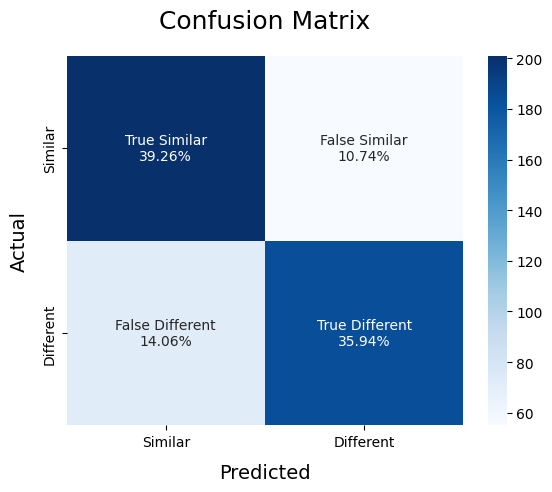

In [20]:
from sklearn.metrics import accuracy_score, confusion_matrix

def ModelMetrics(pos_list, neg_list):
    true = np.array([0]*len(pos_list)+[1]*len(neg_list))
    pred = np.append(pos_list, neg_list)
    
    # Compute and print the accuracy
    print(f"\nAccuracy of model: {accuracy_score(true, pred)}\n")
    
    # Compute and plot the Confusion matrix
    cf_matrix = confusion_matrix(true, pred)

    categories  = ['Similar','Different']
    names = ['True Similar','False Similar', 'False Different','True Different']
    percentages = ['{0:.2%}'.format(value) for value in cf_matrix.flatten() / np.sum(cf_matrix)]

    labels = [f'{v1}\n{v2}' for v1, v2 in zip(names, percentages)]
    labels = np.asarray(labels).reshape(2,2)
    
    sns.heatmap(cf_matrix, annot = labels, cmap = 'Blues',fmt = '',
                xticklabels = categories, yticklabels = categories)

    plt.xlabel("Predicted", fontdict = {'size':14}, labelpad = 10)
    plt.ylabel("Actual"   , fontdict = {'size':14}, labelpad = 10)
    plt.title ("Confusion Matrix", fontdict = {'size':18}, pad = 20)


pos_list = np.array([])
neg_list = np.array([])

for data in get_batch(test_triplets,1,batch_size=256):
    a, p, n = data
    pos_list = np.append(pos_list, classify_images(a, p))
    neg_list = np.append(neg_list, classify_images(a, n))
    break

ModelMetrics(pos_list, neg_list)

In [23]:
import pickle
from tqdm import tqdm


support_set = {}

print("Generating support set prototypes...")
for cls in tqdm(CLASS_NAMES):
    # Get all image paths for this class
    img_paths = train_class_idx[cls]
    
    # Take a sample for the prototype (e.g., 20 images to get a robust average)
    # If the class has fewer than 20, just use all of them
    sample_size = min(20, len(img_paths))
    selected_paths = random.sample(img_paths, sample_size)
    
    batch_imgs = []
    for p in selected_paths:
        img = read_image(IMAGE_ROOT, p) # Use your existing read_image function
        batch_imgs.append(img)
    
    # Preprocess and Encode
    batch_imgs = np.array(batch_imgs, dtype=np.float32)
    batch_imgs = pi_e(batch_imgs) # EfficientNet Preprocess
    embeddings = encoder.predict(batch_imgs, verbose=0)
    
    # Calculate the mean prototype for this class
    prototype = np.mean(embeddings, axis=0)
    support_set[cls] = prototype

# 2. Save the library
with open("support_set.pkl", "wb") as f:
    pickle.dump(support_set, f)

print("Support set saved as support_set.pkl!")

Generating support set prototypes...


  0%|          | 0/101 [00:00<?, ?it/s]2026-06-28 03:38:32.546561: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-28 03:38:32.689284: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-28 03:38:33.046376: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-28 03:38:33.190875: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-28 03:38:33.9

Support set saved as support_set.pkl!
